# 🔬 Exploration — Données brutes S3 (LocalStack)

Ce notebook permet de visualiser les données telles qu'elles arrivent depuis les APIs, **avant tout traitement Spark**.

Il fonctionne en **2 modes** :
- **Mode API directe** : appel direct à FRED pour prévisualiser les données sans pipeline
- **Mode S3** : lecture depuis LocalStack après avoir lancé `batch_extract_fred.py`

In [1]:
import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env")

FRED_API_KEY = os.getenv("FRED_API_KEY")
print(f"✅ Clé FRED chargée : {'Oui' if FRED_API_KEY and FRED_API_KEY != 'VOTRE_CLE_FRED_ICI' else '❌ Non — remplissez .env'}")

✅ Clé FRED chargée : Oui


## 1. Appel direct à l'API FRED

On interroge directement l'API pour voir à quoi ressemble la réponse brute JSON (identique à ce que `batch_extract_fred.py` stocke sur S3).

In [3]:
end_date   = datetime.utcnow().strftime("%Y-%m-%d")
start_date = (datetime.utcnow() - timedelta(days=90)).strftime("%Y-%m-%d")

params = {
    "series_id":          "DCOILWTICO",
    "api_key":            FRED_API_KEY,
    "file_type":          "json",
    "observation_start":  start_date,
    "observation_end":    end_date,
    "frequency":          "d",
    "aggregation_method": "avg",
}

response = requests.get("https://api.stlouisfed.org/fred/series/observations", params=params, timeout=30)
response.raise_for_status()
raw_data = response.json()

print(f"Statut HTTP      : {response.status_code}")
print(f"Période          : {start_date} → {end_date}")
print(f"Nb observations  : {len(raw_data.get('observations', []))}")
print(f"\n--- Clés du JSON retourné par FRED ---")
for key in raw_data.keys():
    print(f"  - {key}")

/tmp/ipykernel_255803/1974319254.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end_date   = datetime.utcnow().strftime("%Y-%m-%d")
/tmp/ipykernel_255803/1974319254.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  start_date = (datetime.utcnow() - timedelta(days=90)).strftime("%Y-%m-%d")


Statut HTTP      : 200
Période          : 2025-11-25 → 2026-02-23
Nb observations  : 61

--- Clés du JSON retourné par FRED ---
  - realtime_start
  - realtime_end
  - observation_start
  - observation_end
  - units
  - output_type
  - file_type
  - order_by
  - sort_order
  - count
  - offset
  - limit
  - observations


## 2. Structure du JSON brut (tel que stocké dans S3)

In [4]:
print("=== EXTRAIT JSON BRUT (identique à s3://datalake/raw/fred/YYYY-MM-DD/wti_price.json) ===\n")
preview = {
    "realtime_start":    raw_data.get("realtime_start"),
    "realtime_end":      raw_data.get("realtime_end"),
    "observation_start": raw_data.get("observation_start"),
    "observation_end":   raw_data.get("observation_end"),
    "units":             raw_data.get("units"),
    "count":             raw_data.get("count"),
    "observations":      raw_data.get("observations", [])[:5],  # 5 premières lignes
}
print(json.dumps(preview, indent=2))

=== EXTRAIT JSON BRUT (identique à s3://datalake/raw/fred/YYYY-MM-DD/wti_price.json) ===

{
  "realtime_start": "2026-02-23",
  "realtime_end": "2026-02-23",
  "observation_start": "2025-11-25",
  "observation_end": "2026-02-23",
  "units": "lin",
  "count": 61,
  "observations": [
    {
      "realtime_start": "2026-02-23",
      "realtime_end": "2026-02-23",
      "date": "2025-11-25",
      "value": "58.25"
    },
    {
      "realtime_start": "2026-02-23",
      "realtime_end": "2026-02-23",
      "date": "2025-11-26",
      "value": "58.81"
    },
    {
      "realtime_start": "2026-02-23",
      "realtime_end": "2026-02-23",
      "date": "2025-11-27",
      "value": "."
    },
    {
      "realtime_start": "2026-02-23",
      "realtime_end": "2026-02-23",
      "date": "2025-11-28",
      "value": "58.58"
    },
    {
      "realtime_start": "2026-02-23",
      "realtime_end": "2026-02-23",
      "date": "2025-12-01",
      "value": "59.47"
    }
  ]
}


## 3. DataFrame brut — problèmes à corriger par Spark

In [5]:
df_raw = pd.DataFrame(raw_data.get("observations", []))

print("=== DataFrame brut (avant nettoyage Spark) ===")
print(f"Shape : {df_raw.shape}\n")
display(df_raw.head(10))

print("\n=== Types de colonnes bruts ===")
print(df_raw.dtypes)
print(f"\n⚠️  'date'  → object (string) : Spark le convertira en TimestampType UTC")
print(f"⚠️  'value' → object (string) : Spark le convertira en DoubleType")
print(f"⚠️  Les valeurs '.' = jours sans cotation (week-ends, jours fériés US)")
print(f"\nNombre de valeurs '.' (manquantes) : {(df_raw['value'] == '.').sum()}")

=== DataFrame brut (avant nettoyage Spark) ===
Shape : (61, 4)



,realtime_start,realtime_end,date,value
0,2026-02-23,2026-02-23,2025-11-25,58.25
1,2026-02-23,2026-02-23,2025-11-26,58.81
2,2026-02-23,2026-02-23,2025-11-27,.
3,2026-02-23,2026-02-23,2025-11-28,58.58
4,2026-02-23,2026-02-23,2025-12-01,59.47
5,2026-02-23,2026-02-23,2025-12-02,58.81
6,2026-02-23,2026-02-23,2025-12-03,59.09
7,2026-02-23,2026-02-23,2025-12-04,59.82
8,2026-02-23,2026-02-23,2025-12-05,60.23
9,2026-02-23,2026-02-23,2025-12-08,59.04



=== Types de colonnes bruts ===
realtime_start    object
realtime_end      object
date              object
value             object
dtype: object

⚠️  'date'  → object (string) : Spark le convertira en TimestampType UTC
⚠️  'value' → object (string) : Spark le convertira en DoubleType
⚠️  Les valeurs '.' = jours sans cotation (week-ends, jours fériés US)

Nombre de valeurs '.' (manquantes) : 5


## 4. Statistiques et visualisation

=== Statistiques prix WTI (USD/baril) — 90 derniers jours ===

count    56.00
mean     59.81
std       2.60
min      55.44
25%      57.86
50%      59.11
75%      61.89
max      64.80

Dernier prix connu : 62.53 $ le 2026-02-17


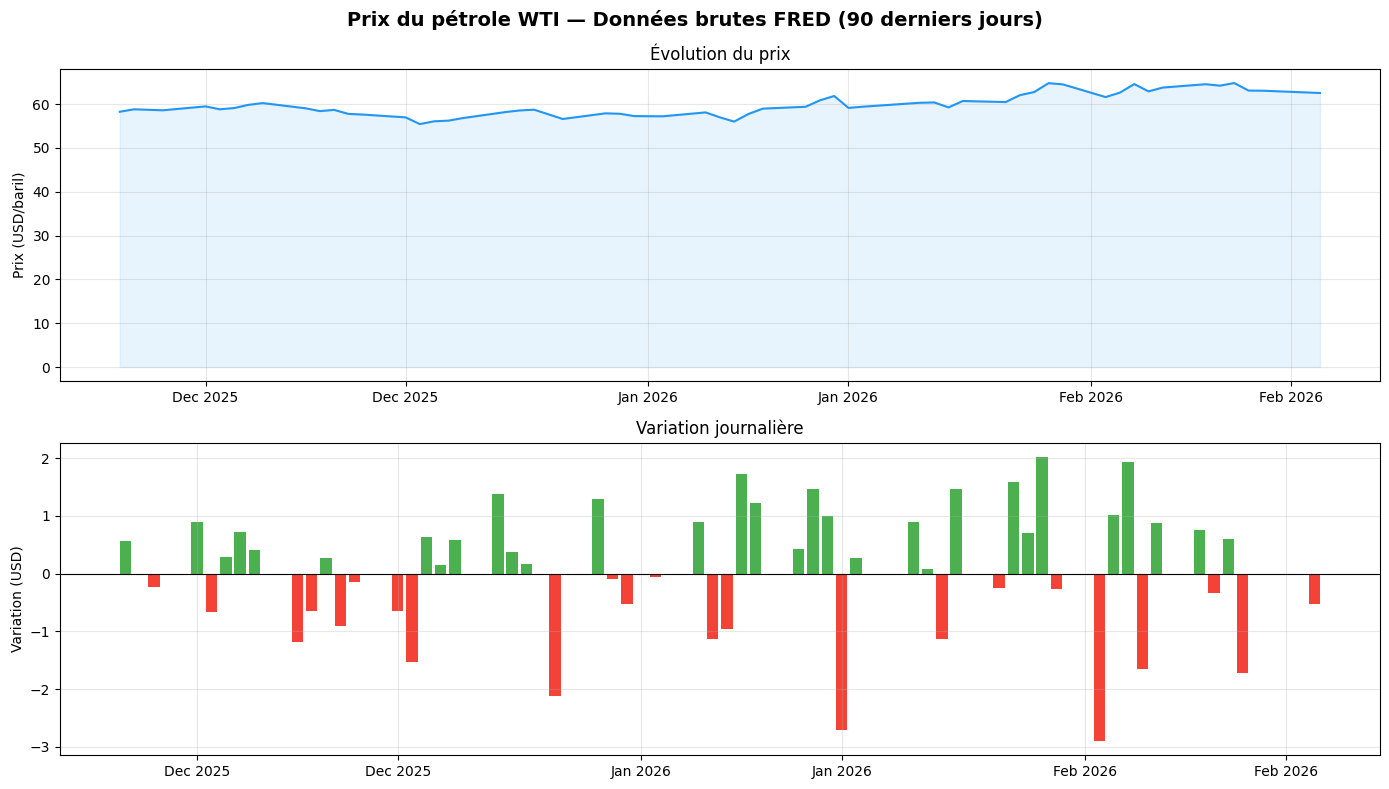


✅ Ces données brutes seront stockées dans : s3://datalake/raw/fred/2026-02-23/wti_price.json
   Puis nettoyées par clean_fred.py (Spark) → s3://datalake/formatted/fred/


In [6]:
# Nettoyage minimal pour visualisation (Spark fera ça proprement)
df = df_raw[["date", "value"]].copy()
df["date"]  = pd.to_datetime(df["date"])
df["value"] = pd.to_numeric(df["value"], errors="coerce")  # '.' → NaN
df_clean    = df.dropna()

print("=== Statistiques prix WTI (USD/baril) — 90 derniers jours ===\n")
print(df_clean["value"].describe().round(2).to_string())
print(f"\nDernier prix connu : {df_clean.iloc[-1]['value']:.2f} $ le {df_clean.iloc[-1]['date'].strftime('%Y-%m-%d')}")

# Graphiques
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Prix du pétrole WTI — Données brutes FRED (90 derniers jours)", fontsize=14, fontweight="bold")

# Évolution du prix
ax1 = axes[0]
ax1.plot(df_clean["date"], df_clean["value"], color="#2196F3", linewidth=1.5)
ax1.fill_between(df_clean["date"], df_clean["value"], alpha=0.1, color="#2196F3")
ax1.set_ylabel("Prix (USD/baril)")
ax1.set_title("Évolution du prix")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.grid(True, alpha=0.3)

# Variation journalière
df_clean = df_clean.copy()
df_clean["variation"] = df_clean["value"].diff()
colors = ["#4CAF50" if v >= 0 else "#F44336" for v in df_clean["variation"].fillna(0)]
ax2 = axes[1]
ax2.bar(df_clean["date"], df_clean["variation"], color=colors, width=0.8)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylabel("Variation (USD)")
ax2.set_title("Variation journalière")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Ces données brutes seront stockées dans : s3://datalake/raw/fred/{end_date}/wti_price.json")
print(f"   Puis nettoyées par clean_fred.py (Spark) → s3://datalake/formatted/fred/")

## 5. Lecture depuis LocalStack S3

Exécutez cette cellule **après avoir lancé** `batch_extract_fred.py` pour vérifier que le fichier est bien sur S3.

In [7]:
import boto3
from botocore.config import Config

s3 = boto3.client(
    "s3",
    endpoint_url=os.getenv("AWS_ENDPOINT_URL", "http://localhost:4566"),
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID", "test"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY", "test"),
    region_name=os.getenv("AWS_DEFAULT_REGION", "eu-west-1"),
    config=Config(signature_version="s3v4"),
)

print("=== Fichiers dans s3://datalake/raw/fred/ ===")
try:
    response = s3.list_objects_v2(Bucket="datalake", Prefix="raw/fred/")
    objects  = response.get("Contents", [])
    if objects:
        for obj in objects:
            size_kb = obj["Size"] / 1024
            print(f"  📄 {obj['Key']}  ({size_kb:.1f} KB)")

        # Lire et afficher le dernier fichier
        last_key = objects[-1]["Key"]
        body = s3.get_object(Bucket="datalake", Key=last_key)["Body"].read()
        data_s3 = json.loads(body)
        df_s3 = pd.DataFrame(data_s3.get("observations", []))
        df_s3["value"] = pd.to_numeric(df_s3["value"], errors="coerce")
        print(f"\n✅ Contenu de {last_key} :")
        display(df_s3.tail(10))
    else:
        print("  ⚠️  Aucun fichier trouvé — lancez d'abord batch_extract_fred.py")
except Exception as e:
    print(f"  ❌ Erreur S3 : {e}")
    print("     → Vérifiez que LocalStack tourne : docker compose -f infrastructure/docker-compose.yml ps")

=== Fichiers dans s3://datalake/raw/fred/ ===
  ❌ Erreur S3 : An error occurred (NoSuchBucket) when calling the ListObjectsV2 operation: The specified bucket does not exist
     → Vérifiez que LocalStack tourne : docker compose -f infrastructure/docker-compose.yml ps
